In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv(r"C:\Users\Prashastini N\Desktop\nassau-candy-profitability-analysis\data\cleaned_data.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Time
0,1,US-2021-103800-CHO-MIL-31000,2024-03-01,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,851
1,2,US-2021-112326-CHO-TRI-54000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,646
2,3,US-2021-112326-CHO-NUT-13000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,646
3,4,US-2021-112326-CHO-SCR-58000,2024-04-01,2026-01-07,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,646
4,5,US-2021-141817-CHO-TRI-54000,2024-05-01,2026-05-07,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,736


In [ ]:
# Top Revenue Contributors (Pareto Analysis)

product_profit = df.groupby("Product Name")["Gross Profit"].sum().sort_values(ascending=False)

pareto_df = product_profit.reset_index()
pareto_df["Cumulative Profit"] = pareto_df["Gross Profit"].cumsum()
pareto_df["Cumulative %"] = pareto_df["Cumulative Profit"] / pareto_df["Gross Profit"].sum() * 100

pareto_df

,Product Name,Gross Profit,Cumulative Profit,Cumulative %
0,Wonka Bar -Scrumdiddlyumptious,19357.50,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,37967.70,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,55411.07,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,72231.02,77.299717
4,Wonka Bar - Fudge Mallows,16593.60,88824.62,95.057747
5,Lickable Wallpaper,3930.00,92754.62,99.263528
6,Wonka Gum,310.70,93065.32,99.596031
7,Everlasting Gobstopper,104.00,93169.32,99.707329
8,Kazookles,92.75,93262.07,99.806588
9,Hair Toffee,59.50,93321.57,99.870263


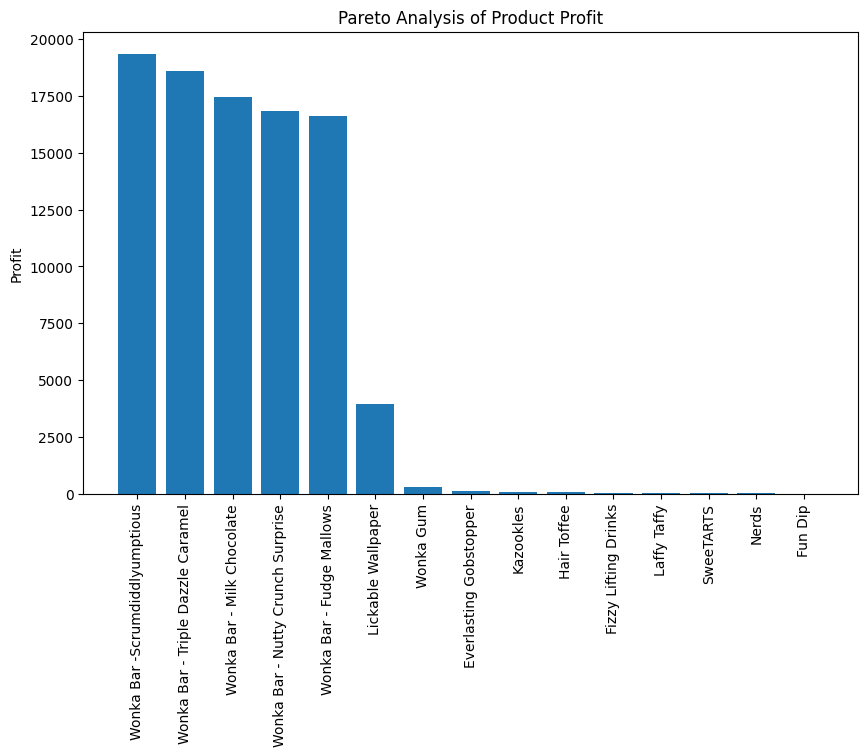

In [8]:
plt.figure(figsize=(10,6))

plt.bar(pareto_df["Product Name"], pareto_df["Gross Profit"])
plt.xticks(rotation=90)

plt.title("Pareto Analysis of Product Profit")
plt.ylabel("Profit")

plt.show()

The Pareto analysis shows that the top five Wonka chocolate bar products generate about 95% of total profit, indicating extremely high profit concentration.  
This confirms the Pareto principle where a small number of products drive the majority of business profitability.

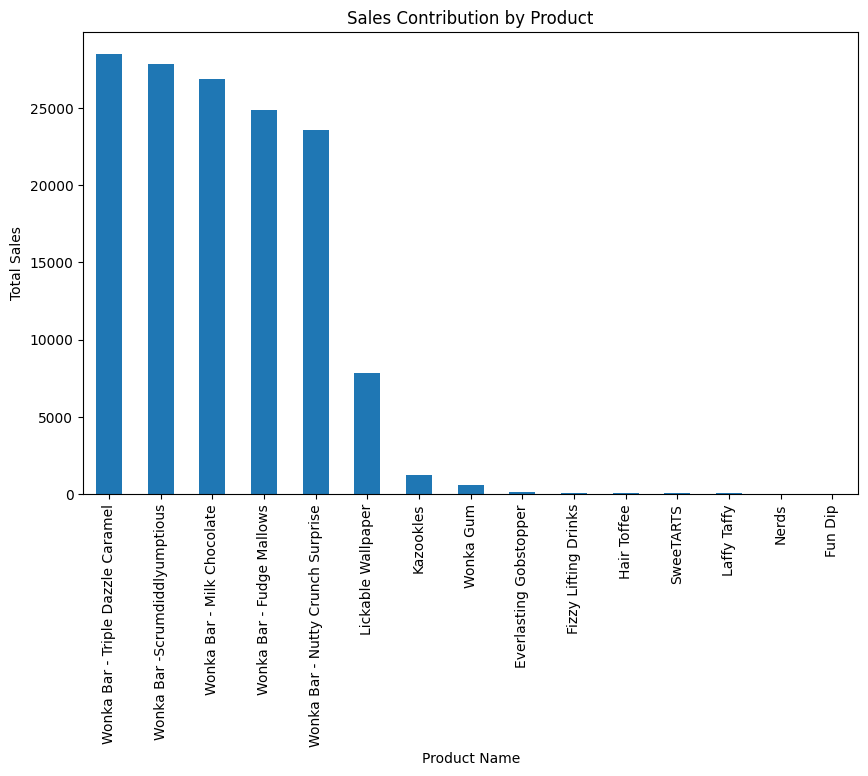

In [9]:
# Sales Contribution by Product

product_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
product_sales.plot(kind="bar")

plt.title("Sales Contribution by Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.show()

Sales distribution is heavily dominated by the Wonka chocolate bar products, which significantly outperform other items in the portfolio.  
Most non-chocolate products contribute very little to overall sales, indicating a strong dependence on a few flagship products.

In [11]:
# Profit Margin vs Sales Efficiency

product_summary = df.groupby("Product Name").agg({
    "Sales":"sum",
    "Gross Profit":"sum"
})

product_summary["Profit Margin %"] = product_summary["Gross Profit"] / product_summary["Sales"] * 100

product_summary

,Sales,Gross Profit,Profit Margin %
Product Name,,,
Everlasting Gobstopper,130.00,104.00,80.000000
Fizzy Lifting Drinks,78.75,47.25,60.000000
Fun Dip,12.00,4.80,40.000000
Hair Toffee,76.50,59.50,77.777778
Kazookles,1205.75,92.75,7.692308
Laffy Taffy,53.73,33.48,62.311558
Lickable Wallpaper,7860.00,3930.00,50.000000
Nerds,15.00,7.00,46.666667
SweeTARTS,61.50,28.70,46.666667


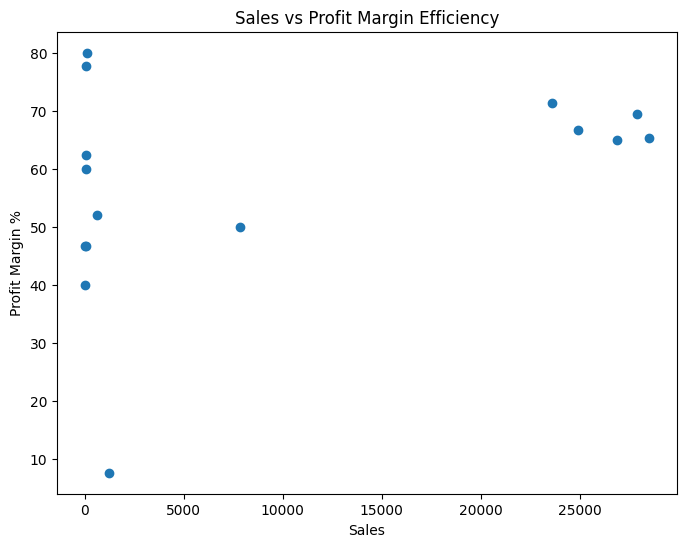

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(product_summary["Sales"], product_summary["Profit Margin %"])

plt.xlabel("Sales")
plt.ylabel("Profit Margin %")
plt.title("Sales vs Profit Margin Efficiency")

plt.show()

Some products such as Everlasting Gobstopper and Hair Toffee have very high profit margins but extremely low sales volumes.  
In contrast, Wonka chocolate bars achieve strong profitability through a balance of high sales and healthy margins.

In [13]:
# Low Performing Products

low_products = product_summary.sort_values("Sales").head()

low_products

,Sales,Gross Profit,Profit Margin %
Product Name,,,
Fun Dip,12.00,4.80,40.000000
Nerds,15.00,7.00,46.666667
Laffy Taffy,53.73,33.48,62.311558
SweeTARTS,61.50,28.70,46.666667
Hair Toffee,76.50,59.50,77.777778


Several products including Fun Dip, Nerds, and Laffy Taffy generate very low sales and minimal profit contribution.  
These products may require marketing improvements, pricing adjustments, or strategic reconsideration within the product portfolio.